<a href="https://colab.research.google.com/github/adcgunwoo/Titantic/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [757]:
# 행렬 연산 관련
import pandas as pd
import numpy as np

# 데이터 시각화 관련
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style = 'white', context = 'notebook', palette = 'deep')

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# 파일 입출력 관련. 제출 파일 만들때 씀
import glob
import os
# 정규식
import re

import statsmodels.api as sm
from sklearn import preprocessing

# 이미 구현된 인공지능 분류 모델, 학습 기법들
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC


from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve

In [758]:
from google import colab
from google.colab import drive
drive.mount('/content/gdrive')
colab_path="/content/gdrive/MyDrive/KISIA/Data/"


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [759]:
df_train = pd.read_csv(colab_path+'train.csv') #df는 data frame의 약자
df_test = pd.read_csv(colab_path+'test.csv') #pd는 pandas의 약
test_y=pd.read_csv(colab_path+'submission.csv')
test_y=test_y['Survived']
print("학습데이터: {}건, 테스트용 데이터: {}건".format(len(df_train), len(df_test)))


학습데이터: 891건, 테스트용 데이터: 418건


In [760]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [761]:
df_train.head() #head메서드 처음 5번째 인원

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [762]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [763]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [764]:
df_train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [765]:
df_train.info()  #Non-Null Count의 숫자의 의미, Age, Cabin, Embarked는 왜 Non-Null Count가 다를까?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [766]:
df_train.describe() #object 컬럼은 빠졌다.
#df_train['Age'].describe -> age만 보고싶다.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [767]:
df_train.shape

(891, 12)

In [768]:
#data셋 전처리 한번에 하기
dataset = [df_train, df_test] #데이터셋 병합
#for data in dataset:
# data.rename(columns = {'Sex' : 'Gender'}, inplace = True)
dataset

[     PassengerId  Survived  Pclass  \
 0              1         0       3   
 1              2         1       1   
 2              3         1       3   
 3              4         1       1   
 4              5         0       3   
 ..           ...       ...     ...   
 886          887         0       2   
 887          888         1       1   
 888          889         0       3   
 889          890         1       1   
 890          891         0       3   
 
                                                   Name     Sex   Age  SibSp  \
 0                              Braund, Mr. Owen Harris    male  22.0      1   
 1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
 2                               Heikkinen, Miss. Laina  female  26.0      0   
 3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
 4                             Allen, Mr. William Henry    male  35.0      0   
 ..                                               

In [769]:
sum(df_train['Survived']==0)/len(df_train['Survived']) #사망자 비율

0.6161616161616161

In [770]:
df_train['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [771]:
df_train[df_train['Embarked'].isnull()] #탑승지가 비어있음

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [772]:
df_train.groupby(['Pclass','Embarked'])['Fare'].mean() #등급별 그리고 탑승지별 요금

Pclass  Embarked
1       C           104.718529
        Q            90.000000
        S            70.364862
2       C            25.358335
        Q            12.350000
        S            20.327439
3       C            11.214083
        Q            11.183393
        S            14.644083
Name: Fare, dtype: float64

In [773]:
df_train.groupby('Embarked')['Pclass'].value_counts() #groupby는 어떤 함수일까? column을 합쳐서 볼 수 있나보다.

Embarked  Pclass
C         1          85
          3          66
          2          17
Q         3          72
          2           3
          1           2
S         3         353
          2         164
          1         127
Name: count, dtype: int64

In [774]:
df_train['Fare'].describe() #요금 평균

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [775]:
df_train[df_train['Fare'] ==  512.329200] #가장 비싼 돈을 주고 탄 사람들

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [776]:
df_alldata[df_alldata['Fare'] ==  512.329200] #데이터를 합친 전부(test와 train을 합침), 마지막 여성은 우리가 예측해야

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
258,259,1.0,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,0.0,Miss
679,680,1.0,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,0.0,Mr
737,738,1.0,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,0.0,Mr
343,1235,NaN,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,NaN,NaN


In [777]:
df_train['Ticket'].value_counts() #티켓 번호 조회, 같은 티켓 번호가 동일한것들이 있다.

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [778]:
df_alldata['Ticket'].value_counts()

,count
Ticket,
CA. 2343,11
1601,8
CA 2144,8
347082,7
S.O.C. 14879,7
...,...
A.5. 3236,1
347086,1
365237,1


In [779]:
df_alldata[df_alldata['Ticket'] == 'CA. 2343'] #같은 표를 산 인원들(train+test) 성이 다들 같네, Sibsp+Parch는 10으로 동일하다.
#여기서 나까지 포함해서 총 11명인 것이다.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
159,160,0.0,3,"Sage, Master. Thomas Henry",male,4.574167,8,2,CA. 2343,69.55,NaN,S,1.0,Master
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,21.773973,8,2,CA. 2343,69.55,NaN,S,1.0,Miss
201,202,0.0,3,"Sage, Mr. Frederick",male,32.368090,8,2,CA. 2343,69.55,NaN,S,1.0,Mr
324,325,0.0,3,"Sage, Mr. George John Jr",male,32.368090,8,2,CA. 2343,69.55,NaN,S,1.0,Mr
792,793,0.0,3,"Sage, Miss. Stella Anna",female,21.773973,8,2,CA. 2343,69.55,NaN,S,1.0,Miss
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,32.368090,8,2,CA. 2343,69.55,NaN,S,1.0,Mr
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,21.773973,8,2,CA. 2343,69.55,NaN,S,1.0,Miss
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S,NaN,NaN
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S,NaN,NaN
360,1252,NaN,3,"Sage, Master. William Henry",male,14.500000,8,2,CA. 2343,69.55,NaN,S,NaN,NaN


In [780]:
df=pd.concat(dataset, axis=0) #무슨 메서드일까
print(len(df))
df.reset_index(drop=True)

1309


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [781]:
replace_value=df_train['Embarked'].value_counts(dropna=False).idxmax() #무슨 메서드일까
replace_value

'S'

In [782]:
# 결측치 처리(대체) - Embarked
df_train['Embarked'] = df_train['Embarked'].fillna(replace_value) #null 자리에 'S'를 채워넣겠다는 의미

In [783]:
df_train['Embarked'].isna().sum() #nan인게 없어진것을 확인할 수 있다.

np.int64(0)

In [784]:
df_train[df_train['Embarked'].isna()]['Survived']==1 #뭘 나타낼까?

,Survived


In [785]:
sum(df_train['Age'].isna()) #isna() 메서드는 뭘까

177

In [786]:
df_train[df_train['Age'].isna()]['Survived'].mean()

np.float64(0.2937853107344633)

In [787]:
df_train['Age'].isna().astype(int)

,Age
0,0
1,0
2,0
3,0
4,0
...,...
886,0
887,0
888,1
889,0


In [788]:
df_train['Age_isna'] = df_train['Age'].isna().astype(int)
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


In [789]:
df_train[df_train['Age'].isna()]['Survived']==1 #뭘 나타낼까?
#sum(df_train[df_train['Age'].isna()]['Survived']==1)/177


,Survived
5,False
17,True
19,True
26,False
28,True
...,...
859,False
863,False
868,False
878,False


In [790]:
df_train['Age_isna']=df_train['Age'].isna().astype(int)
df_train
#나이가 Nan인 사람들인데 이름 가운데에 master(존칭)는 어리겠지 ex. 도련님

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


In [791]:
df_train[df_train['Name'].str.contains('Master')].describe() #master 호칭(어린 남성)은 가진 사람의 나이와 동승자 숫자 그리고 생존률을 유심히 봐라
#mean은 평균, Fare / (Sibsp + Parch) 는 표값이다?

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,40.000000,40.000000,40.000000,36.000000,40.000000,40.000000,40.000000,40.000000
mean,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,34.703125,0.100000
std,301.717518,0.500641,0.627878,3.619872,1.910833,0.540062,28.051752,0.303822
min,8.000000,0.000000,1.000000,0.420000,0.000000,0.000000,8.516700,0.000000
25%,165.750000,0.000000,2.000000,1.000000,1.000000,1.000000,18.750000,0.000000
50%,345.000000,1.000000,3.000000,3.500000,1.000000,1.000000,29.062500,0.000000
75%,764.000000,1.000000,3.000000,8.000000,4.000000,2.000000,39.171875,0.000000
max,870.000000,1.000000,3.000000,12.000000,8.000000,2.000000,151.550000,1.000000


In [792]:
df_train[df_train['Name'].str.contains('Mr\.')].describe()
#이름 가운데에 Mr 있는 애들(성인남성)은 생존률이 15%밖에 안된다.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,517.000000,517.000000,517.000000,398.000000,517.000000,517.000000,517.000000,517.000000
mean,454.499033,0.156673,2.410058,32.368090,0.288201,0.152805,24.441560,0.230174
std,253.715526,0.363844,0.810622,12.708793,0.821298,0.533615,44.378561,0.421352
min,1.000000,0.000000,1.000000,11.000000,0.000000,0.000000,0.000000,0.000000
25%,226.000000,0.000000,2.000000,23.000000,0.000000,0.000000,7.800000,0.000000
50%,466.000000,0.000000,3.000000,30.000000,0.000000,0.000000,9.350000,0.000000
75%,674.000000,0.000000,3.000000,39.000000,0.000000,0.000000,26.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200,1.000000


In [793]:
df_train[df_train['Name'].str.contains('Mrs\.')].describe()
#이름 가운데에 Mrs인 애들은 생존률이 80%이다.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,125.000000,125.00000,125.000000,108.000000,125.000000,125.000000,125.000000,125.000000
mean,453.160000,0.79200,2.000000,35.898148,0.696000,0.832000,45.138533,0.136000
std,270.762764,0.40751,0.823055,11.433628,0.598708,1.274666,45.723716,0.344168
min,2.000000,0.00000,1.000000,14.000000,0.000000,0.000000,7.225000,0.000000
25%,255.000000,1.00000,1.000000,27.750000,0.000000,0.000000,15.850000,0.000000
50%,438.000000,1.00000,2.000000,35.000000,1.000000,0.000000,26.000000,0.000000
75%,679.000000,1.00000,3.000000,44.000000,1.000000,1.000000,57.000000,0.000000
max,886.000000,1.00000,3.000000,63.000000,3.000000,6.000000,247.520800,1.000000


In [794]:
df_train_TitleAge = df_train #타이틀(호칭)별 평균 나이로 결측치 대체가 의미있는지 검토

In [795]:
df_train_TitleAge['Title'] = df_train['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())

In [796]:
df_train_TitleAge

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,Mr


In [797]:
df_train_TitleAge = df_train
df_train_TitleAge['Title'].value_counts() #전체 타이틀(호칭) 출력

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [798]:
df_train_TitleAge['Title'].str.contains('Mr, Miss, Mrs, Master').value_counts()

,count
Title,
False,891


In [799]:
Majot_Titles = ['Mr', 'Mrs', 'Miss', 'Master']
df_train_TitleAge['Title'] = df_train_TitleAge['Title'].apply(lambda x: x if x in Majot_Titles else 'Other') #많은 4개의 호칭을 other로 합치기
df_train_TitleAge['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Other,27


In [800]:
#print(df_train['Title'].isnull().value_counts())
title_age_mean = df_train_TitleAge.groupby('Title')['Age'].mean().to_dict()
title_age_replace_value = df_train_TitleAge['Title'].map(title_age_mean)
df_train_TitleAge['Age'] = df_train_TitleAge['Age'].fillna(title_age_replace_value)      #age 평균 값 넣어주기

In [801]:
df_train_TitleAge.loc[
    (df_train_TitleAge['Title'] == 'Other') & (df_train_TitleAge['Sex'] =='male'),
    'Title'
] = 'Mr'

In [802]:
df_train_TitleAge.loc[
    (df_train_TitleAge['Title'] == 'Other') & (df_train_TitleAge['Sex'] =='female'),
    'Title'
] = 'Mrs'

In [803]:
df_train_TitleAge['Title'].value_counts()

,count
Title,
Mr,537
Miss,182
Mrs,132
Master,40


In [804]:
columns = df_train_TitleAge.columns

In [805]:
df_train = df_train_TitleAge

In [806]:
title_age_mean = df_train_TitleAge.groupby('Title')['Age'].mean().to_dict()
title_age_mean

{'Master': 4.574166666666667,
 'Miss': 21.773972602739725,
 'Mr': 32.86533962607768,
 'Mrs': 35.73688271604938}

In [807]:
title_age_mean = df_train_TitleAge.groupby('Title')['Age'].mean().to_dict()
title_age_replace_value = df_train_TitleAge['Title'].map(title_age_mean)
df_train_TitleAge['Age'] = df_train_TitleAge['Age'].fillna(title_age_replace_value)

In [808]:
df_train[df_train['Title']=='Master'] #Master들의 평균이 missing data에 들어갔다.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S,0,Master
16,17,0,3,"Rice, Master. Eugene",male,2.000000,4,1,382652,29.1250,NaN,Q,0,Master
50,51,0,3,"Panula, Master. Juha Niilo",male,7.000000,4,1,3101295,39.6875,NaN,S,0,Master
59,60,0,3,"Goodwin, Master. William Frederick",male,11.000000,5,2,CA 2144,46.9000,NaN,S,0,Master
63,64,0,3,"Skoog, Master. Harald",male,4.000000,3,2,347088,27.9000,NaN,S,0,Master
65,66,1,3,"Moubarek, Master. Gerios",male,4.574167,1,1,2661,15.2458,NaN,C,1,Master
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.830000,0,2,248738,29.0000,NaN,S,0,Master
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12.000000,1,0,2651,11.2417,NaN,C,0,Master
159,160,0,3,"Sage, Master. Thomas Henry",male,4.574167,8,2,CA. 2343,69.5500,NaN,S,1,Master
164,165,0,3,"Panula, Master. Eino Viljami",male,1.000000,4,1,3101295,39.6875,NaN,S,0,Master


In [809]:
#title_list = df_train_TitleAge['Title'].unique()
#title_map = {title: idx for idx, title in enumerate(sorted(title_list))}
#title_map

In [810]:
df_train[df_train['Name'].str.contains('Miss\.')].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,408.884615,0.697802,2.307692,21.773973,0.714286,0.549451,43.797873,0.197802
std,246.775812,0.460477,0.849989,11.626892,1.431961,0.804184,66.027199,0.399441
min,3.000000,0.000000,1.000000,0.750000,0.000000,0.000000,6.750000,0.000000
25%,213.000000,0.000000,1.250000,16.000000,0.000000,0.000000,7.951050,0.000000
50%,381.500000,1.000000,3.000000,21.773973,0.000000,0.000000,15.620850,0.000000
75%,612.250000,1.000000,3.000000,26.750000,1.000000,1.000000,41.034400,0.000000
max,889.000000,1.000000,3.000000,63.000000,8.000000,2.000000,512.329200,1.000000


In [811]:
replace_value = df_train['Age'].mean().round(2)
replace_value #나이 그냥 있는 것들의 평균으로 계산해서 결측치를 처리할 수 있다.(머리 쓰지 말고 간단하게 할 때)

np.float64(29.76)

In [812]:
# 결측치 처리(대체) - Age
#df_train['Age'] = df_train['Age'].fillna(replace_value) 실행하면 다 날라가니까 주석처리

In [813]:
df_train.isna().sum() #cabin만 남았다.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [814]:
#결측치 처리 - Cabin
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_isna', 'Title'],
      dtype='object')

In [815]:
# 결측치 처리 - Cabin
df_cabin_notnull = df_train.dropna(subset=['Cabin'])
for pclass in range(1,4):
    cabin_values = df_cabin_notnull[df_cabin_notnull['Pclass'] == pclass]['Cabin'].sort_values().values
    print ("Pclass {}에 해당하는 Cabin의 값: {}\n".format(pclass, cabin_values))

Pclass 1에 해당하는 Cabin의 값: ['A10' 'A14' 'A16' 'A19' 'A20' 'A23' 'A24' 'A26' 'A31' 'A32' 'A34' 'A36'
 'A5' 'A6' 'A7' 'B101' 'B102' 'B18' 'B18' 'B19' 'B20' 'B20' 'B22' 'B22'
 'B28' 'B28' 'B3' 'B30' 'B35' 'B35' 'B37' 'B38' 'B39' 'B4' 'B41' 'B42'
 'B49' 'B49' 'B5' 'B5' 'B50' 'B51 B53 B55' 'B51 B53 B55' 'B57 B59 B63 B66'
 'B57 B59 B63 B66' 'B58 B60' 'B58 B60' 'B69' 'B71' 'B73' 'B77' 'B77' 'B78'
 'B79' 'B80' 'B82 B84' 'B86' 'B94' 'B96 B98' 'B96 B98' 'B96 B98' 'B96 B98'
 'C101' 'C103' 'C104' 'C106' 'C110' 'C111' 'C118' 'C123' 'C123' 'C124'
 'C124' 'C125' 'C125' 'C126' 'C126' 'C128' 'C148' 'C2' 'C2' 'C22 C26'
 'C22 C26' 'C22 C26' 'C23 C25 C27' 'C23 C25 C27' 'C23 C25 C27'
 'C23 C25 C27' 'C30' 'C32' 'C45' 'C46' 'C47' 'C49' 'C50' 'C52' 'C52' 'C54'
 'C62 C64' 'C65' 'C65' 'C68' 'C68' 'C7' 'C70' 'C78' 'C78' 'C82' 'C83'
 'C83' 'C85' 'C86' 'C87' 'C90' 'C91' 'C92' 'C92' 'C93' 'C93' 'C95' 'C99'
 'D10 D12' 'D11' 'D15' 'D17' 'D17' 'D19' 'D20' 'D20' 'D21' 'D26' 'D26'
 'D28' 'D30' 'D33' 'D33' 'D35' 'D35' 'D36

In [816]:
# 결측치 처리(해당 Feature 분석에서 제외) - Cabin 아예 column을 지워버림, 이거 실행하면 아래에서 Cabin이 삭제된다.
#df_train = df_train.drop(columns=['Cabin'])
#df_train_TitleAge = df_train_TitleAge.drop(columns=['Cabin'])

In [817]:
pclass_fare_mean = df_train_TitleAge.groupby('Pclass')['Fare'].mean().to_dict()
pclass_fare_mean #평균값을 냈는데, 만약 missin 데이터가 있다면 채울 수 있다.

{1: 84.1546875, 2: 20.662183152173913, 3: 13.675550101832993}

In [818]:
#test 데이터가 null인 경우
plcass_fare_mean = df_train_TitleAge.groupby('Pclass')['Fare'].mean().to_dict()
plcass_fare_replace_value = df_train_TitleAge['Pclass'].map(title_age_mean)
df_train_TitleAge['Fare'] = df_train_TitleAge['Fare'].fillna(title_age_replace_value)      #age 평균 값 넣어주기

In [819]:
df_merged_train = pd.concat([df_train[df_train['Name'].str.contains('Master')].fillna(5), df_train[df_train['Name'].str.contains('Master')==False].fillna(29)], axis=0) #왜 안되니
df_merged_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [820]:
dataset = [df_train, df_test]
#for data in dataset:
#    data.rename(columns = {'Sex' : 'Gender'}, inplace=True)
dataset
df_alldata = pd.concat(dataset, axis=0)
df_alldata

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.0,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.0,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,NaN,NaN
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,NaN,NaN
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,NaN,NaN
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,NaN,NaN


In [821]:
print((df_train['Survived'].value_counts()/len(df_train)*100).round(2)) #훈련데이터의 생존자 사망자 비율

Survived
0    61.62
1    38.38
Name: count, dtype: float64


In [822]:
#print((df_test['Survived'].value_counts()/len(df_train)*100).round(2)) 아직 NUll이어서 불가

In [823]:
#결측치 확인
print('### train dataset ###')
print(df_train.isnull().mean()) #결측치의 개수, age가 왜 안뜨지
print('### test data set ###')
print(df_test.isnull().mean()) #결측치의 개수

### train dataset ###
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.000000
Age_isna       0.000000
Title          0.000000
dtype: float64
### test data set ###
PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64


In [824]:
df_train['Age'].describe()

,Age
count,891.000000
mean,29.755090
std,13.277584
min,0.420000
25%,21.773973
50%,30.000000
75%,35.898148
max,80.000000


In [825]:
# SibSp(함께 탑승한 형제, 자매, 아내, 남편의 수) unique값
df_train['SibSp'].value_counts().sort_index()

,count
SibSp,
0,608
1,209
2,28
3,16
4,18
5,5
8,7


In [826]:
# Parch(함께 탑승한 부모, 자식의 수) unique값
df_train['Parch'].value_counts().sort_index()

,count
Parch,
0,678
1,118
2,80
3,5
4,4
5,5
6,1


{'whiskers': [<matplotlib.lines.Line2D at 0x7e41beb19400>,
 'caps': [<matplotlib.lines.Line2D at 0x7e41beb19a30>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e41beb19100>],
 'medians': [<matplotlib.lines.Line2D at 0x7e41beb19fd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e41beb1a270>],
 'means': []}

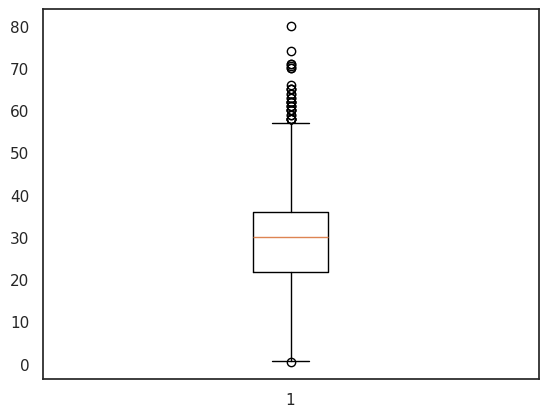

In [827]:
# Age 값 BoxPlot으로 확인
plt.boxplot([df_train['Age']])

{'whiskers': [<matplotlib.lines.Line2D at 0x7e41beacfc50>,
 'caps': [<matplotlib.lines.Line2D at 0x7e41beb302c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e41beacfa10>],
 'medians': [<matplotlib.lines.Line2D at 0x7e41beb30740>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e41beb30a10>],
 'means': []}

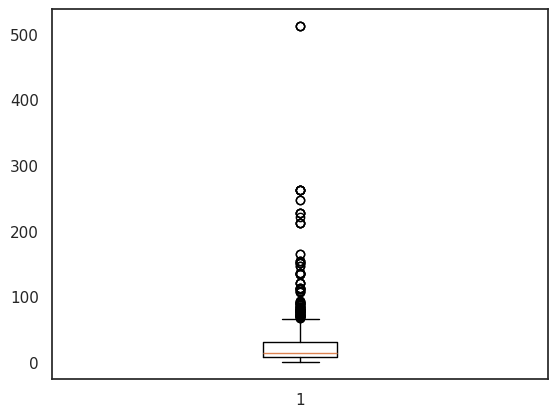

In [828]:
#Fare값 BoxPlot으로 보기
plt.boxplot([df_train['Fare']])

In [829]:
df_train[df_train['Fare'] < 5 ][['Fare', 'Survived']]

,Fare,Survived
179,0.0000,0
263,0.0000,0
271,0.0000,1
277,0.0000,0
302,0.0000,0
378,4.0125,0
413,0.0000,0
466,0.0000,0
481,0.0000,0
597,0.0000,0


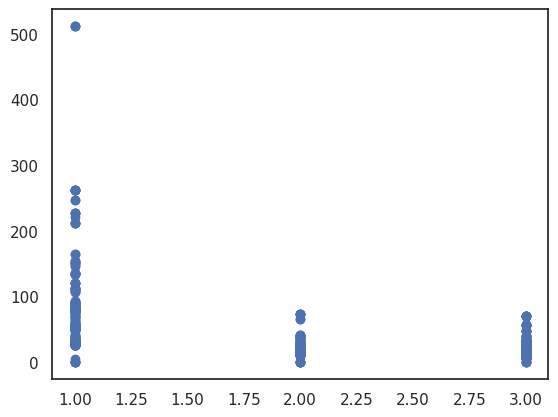

In [830]:
# Fare 데이터 자세히 들여다보기 - Pclass별로
plt.scatter(df_train['Pclass'], df_train['Fare']) #0원은 무임승차인가?

([<matplotlib.axis.XTick at 0x7e41bea92d20>,
 [Text(1, 0, 'Age'), Text(2, 0, 'Fare')])

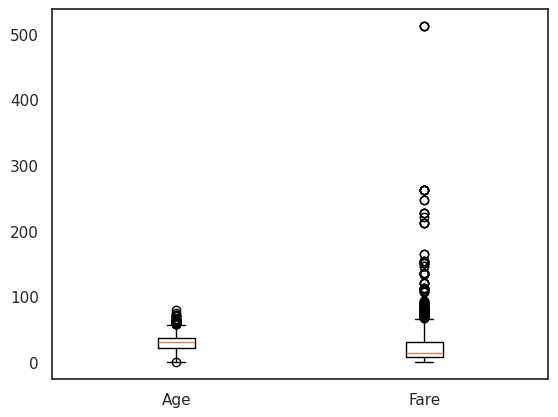

In [831]:
# Age, Fare 값 BoxPlot으로 확인
plt.boxplot([df_train['Age'], df_train['Fare']])
plt.xticks([1, 2],['Age', 'Fare'])

In [832]:
# Fare 데이터 자세히 들여다보기 - 실제 샘플 확인
df_train.sort_values(by=['Fare'], ascending=False).head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,0,Mr
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,0,Miss
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,0,Mr
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,0,Miss
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,0,Mr


### **이상치 처리** (반드시 정규화 전에 이루어져야 한다.)

In [833]:
from sklearn import preprocessing

# Age, Fare에 대해 z-score 정규화
columns_to_scale = ['Age', 'Fare']
#scaler_train = preprocessing.MinMaxScaler() #Min값과 Max값을 이용
scaler_train = preprocessing.StandardScaler() #위 함수와 동일하다. 표준편차를 이용
# 나중에 테스트 데이터에 적용하기 위하여 fit 단계와 transform 단계를 분리한다.
scaler_train = scaler_train.fit(df_train[columns_to_scale])

df_train[columns_to_scale] = scaler_train.transform(df_train[columns_to_scale])
df_train
# X_new = (X-min) / (max-min)
# X_new = (X - m) / σ

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isna,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.584402,1,0,A/5 21171,-0.502445,NaN,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.621313,1,0,PC 17599,0.786845,C85,C,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.282973,0,0,STON/O2. 3101282,-0.488854,NaN,S,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.395242,1,0,113803,0.420730,C123,S,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,0.395242,0,0,373450,-0.486337,NaN,S,0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,-0.207616,0,0,211536,-0.386671,NaN,S,0,Mr
887,888,1,1,"Graham, Miss. Margaret Edith",female,-0.810474,0,0,112053,-0.044381,B42,S,0,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,-0.601435,1,2,W./C. 6607,-0.176263,NaN,S,1,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,-0.282973,0,0,111369,-0.044381,C148,C,0,Mr


# 정규화(gredient, descent 안 쓸거면 정규화 안해도 된다.)


In [834]:
df_train.describe() #Pclass값 주목

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_isna
count,891.000000,891.000000,891.000000,8.910000e+02,891.000000,891.000000,8.910000e+02,891.000000
mean,446.000000,0.383838,2.308642,1.594933e-16,0.523008,0.381594,3.987333e-18,0.198653
std,257.353842,0.486592,0.836071,1.000562e+00,1.102743,0.806057,1.000562e+00,0.399210
min,1.000000,0.000000,1.000000,-2.210611e+00,0.000000,0.000000,-6.484217e-01,0.000000
25%,223.500000,0.000000,2.000000,-6.014348e-01,0.000000,0.000000,-4.891482e-01,0.000000
50%,446.000000,0.000000,3.000000,1.845570e-02,0.000000,0.000000,-3.573909e-01,0.000000
75%,668.500000,1.000000,3.000000,4.629237e-01,1.000000,0.000000,-2.424635e-02,0.000000
max,891.000000,1.000000,3.000000,3.786316e+00,8.000000,6.000000,9.667167e+00,1.000000


In [835]:
# Sex(성별), Embarked(배에 탑승한 위치) 데이터 인코딩
df_train = pd.get_dummies(df_train, columns = ['Sex', 'Embarked'])
df_train.iloc[:, -5:]

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,False,True
1,True,False,True,False,False
2,True,False,False,False,True
3,True,False,False,False,True
4,False,True,False,False,True
...,...,...,...,...,...
886,False,True,False,False,True
887,True,False,False,False,True
888,True,False,False,False,True
889,False,True,True,False,False


In [836]:
df_train

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Age_isna,Title,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.584402,1,0,A/5 21171,-0.502445,NaN,0,Mr,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.621313,1,0,PC 17599,0.786845,C85,0,Mrs,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.282973,0,0,STON/O2. 3101282,-0.488854,NaN,0,Miss,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.395242,1,0,113803,0.420730,C123,0,Mrs,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.395242,0,0,373450,-0.486337,NaN,0,Mr,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",-0.207616,0,0,211536,-0.386671,NaN,0,Mr,False,True,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",-0.810474,0,0,112053,-0.044381,B42,0,Miss,True,False,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",-0.601435,1,2,W./C. 6607,-0.176263,NaN,1,Miss,True,False,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",-0.282973,0,0,111369,-0.044381,C148,0,Mr,False,True,True,False,False


In [837]:
df_train_TitleAge['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [838]:
df_train_TitleAge['Title'].value_counts()

,count
Title,
Mr,537
Miss,182
Mrs,132
Master,40


In [839]:
df_train_TitleAge.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_isna', 'Title'],
      dtype='object')

In [840]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [841]:
df_train.iloc[:, -5:]

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,False,True
1,True,False,True,False,False
2,True,False,False,False,True
3,True,False,False,False,True
4,False,True,False,False,True
...,...,...,...,...,...
886,False,True,False,False,True
887,True,False,False,False,True
888,True,False,False,False,True
889,False,True,True,False,False


In [842]:
# Sex(성별), Embarked(배에 탑승한 위치) 데이터 인코딩
df_train = pd.get_dummies(df_train, columns = ['Title'])
df_train.iloc[:, -5:]

,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,True,False,False,True,False
1,False,False,False,False,True
2,True,False,True,False,False
3,True,False,False,False,True
4,True,False,False,True,False
...,...,...,...,...,...
886,True,False,False,True,False
887,True,False,True,False,False
888,True,False,True,False,False
889,False,False,False,True,False


In [843]:
df_train

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Age_isna,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,1,0,3,"Braund, Mr. Owen Harris",-0.584402,1,0,A/5 21171,-0.502445,NaN,0,False,True,False,False,True,False,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.621313,1,0,PC 17599,0.786845,C85,0,True,False,True,False,False,False,False,False,True
2,3,1,3,"Heikkinen, Miss. Laina",-0.282973,0,0,STON/O2. 3101282,-0.488854,NaN,0,True,False,False,False,True,False,True,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.395242,1,0,113803,0.420730,C123,0,True,False,False,False,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.395242,0,0,373450,-0.486337,NaN,0,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",-0.207616,0,0,211536,-0.386671,NaN,0,False,True,False,False,True,False,False,True,False
887,888,1,1,"Graham, Miss. Margaret Edith",-0.810474,0,0,112053,-0.044381,B42,0,True,False,False,False,True,False,True,False,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",-0.601435,1,2,W./C. 6607,-0.176263,NaN,1,True,False,False,False,True,False,True,False,False
889,890,1,1,"Behr, Mr. Karl Howell",-0.282973,0,0,111369,-0.044381,C148,0,False,True,True,False,False,False,False,True,False


In [844]:
# Name에 포함된 호칭 추출하여 확인
# 정규표현식은 학습범위를 벗어나므로 결과만을 참고한다.
df_train['Name'].str.extract("([A-Za-z]+)\.").value_counts(dropna=False)

,count
0,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Mlle,2
Major,2
Col,2


In [845]:
# 이름에 'Master', 'Dr', 'Rev(목사)', 'Major', 'Col(대령)', 'Capt', 'Jonkheer(귀족)', 'Don', 'Countess(백작)', 'Sir＇ 포함 여부를 Flag화 한다.
df_train['Name_has_title'] = df_train['Name'].str.contains('Master|Dr|Rev|Major|Col|Capt|Jonkheer|Don|Countess|Sir').astype(int)

In [846]:
df_train['Name_has_title'].value_counts()

,count
Name_has_title,
0,814
1,77


In [847]:
# Name, Ticket 필드 분석에서 제외
df_train = df_train.drop(columns=['Ticket', 'Name'])

In [848]:
df_train['Name_has_title'].value_counts()

,count
Name_has_title,
0,814
1,77


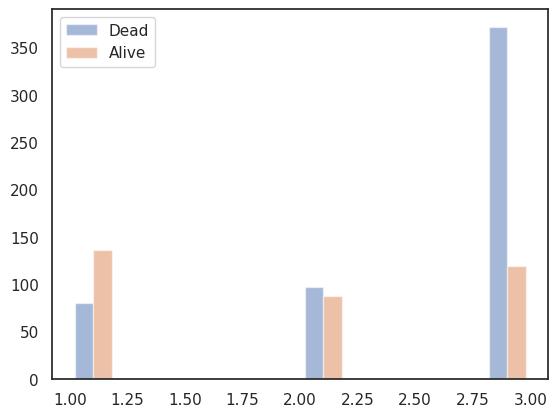

In [849]:
# Pclass에 따른 Survived(사망자/생존자) 분포
hist1 = df_train[df_train['Survived']==0]['Pclass']
hist2 = df_train[df_train['Survived']==1]['Pclass']
plt.hist([hist1, hist2], label=['Dead', 'Alive'], alpha=0.5)
plt.legend(loc=0)
#일등실의 사망률이 낮다.

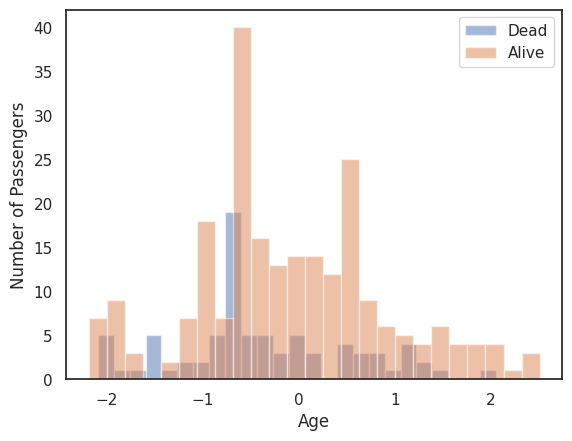

In [850]:
# 여성 나이 별 Survived(사망자/생존자) 분포
hist1 = df_train[(df_train['Survived']==0) & (df_train['Sex_female'])]['Age']
hist2 = df_train[(df_train['Survived']==1) & (df_train['Sex_female'])]['Age']
plt.hist(hist1, label='Dead', bins=25, alpha=0.5)
plt.hist(hist2, label='Alive', bins=25, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend(loc=0)

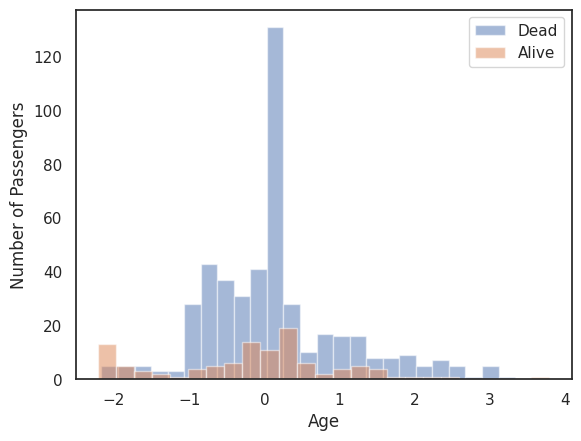

In [851]:
# 남성 나이 별 Survived(사망자/생존자) 분포
hist1 = df_train[(df_train['Survived']==0) & (df_train['Sex_male'])]['Age']
hist2 = df_train[(df_train['Survived']==1) & (df_train['Sex_male'])]['Age']
plt.hist(hist1, label='Dead', bins=25, alpha=0.5)
plt.hist(hist2, label='Alive', bins=25, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend(loc=0)

In [852]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Cabin', 'Age_isna', 'Sex_female', 'Sex_male', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Name_has_title'],
      dtype='object')

In [853]:
# 상관관계 계산(숫자로 보기, 보기 어려움)
cols_to_corr = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs']
df_train[cols_to_corr].corr().round(2)

,Pclass,Age,SibSp,Parch,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs
Pclass,1.00,-0.34,0.08,0.02,-0.55,0.08,-0.00,0.09,-0.18
Age,-0.34,1.00,-0.27,-0.20,0.09,-0.41,-0.30,0.29,0.19
SibSp,0.08,-0.27,1.00,0.41,0.16,0.35,0.09,-0.26,0.05
Parch,0.02,-0.20,0.41,1.00,0.22,0.27,0.11,-0.35,0.21
Fare,-0.55,0.09,0.16,0.22,1.00,0.01,0.12,-0.18,0.11
Title_Master,0.08,-0.41,0.35,0.27,0.01,1.00,-0.11,-0.27,-0.09
Title_Miss,-0.00,-0.30,0.09,0.11,0.12,-0.11,1.00,-0.62,-0.21
Title_Mr,0.09,0.29,-0.26,-0.35,-0.18,-0.27,-0.62,1.00,-0.51
Title_Mrs,-0.18,0.19,0.05,0.21,0.11,-0.09,-0.21,-0.51,1.00


([<matplotlib.axis.YTick at 0x7e41be361190>,
 [Text(0, 0.5, 'Pclass'),
  Text(0, 1.5, 'Age'),
  Text(0, 2.5, 'SibSp'),
  Text(0, 3.5, 'Parch'),
  Text(0, 4.5, 'Fare'),
  Text(0, 5.5, 'Title_Master'),
  Text(0, 6.5, 'Title_Miss'),
  Text(0, 7.5, 'Title_Mr'),
  Text(0, 8.5, 'Title_Mrs')])

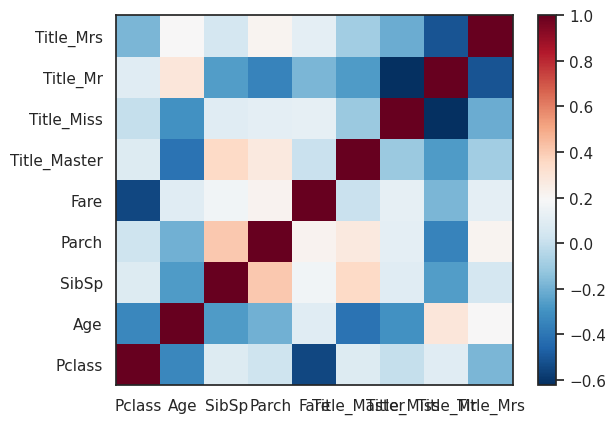

In [854]:
# 상관관계 시각화
cols_to_corr = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs']
fig, ax = plt.subplots(1, 1)
c = ax.pcolor(df_train[cols_to_corr].corr().round(2), cmap='RdBu_r')
fig.colorbar(c, ax=ax)
plt.xticks(np.arange(0.5, len(cols_to_corr), 1), cols_to_corr)
plt.yticks(np.arange(0.5, len(cols_to_corr), 1), cols_to_corr)

In [855]:
df_train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Age_isna,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Name_has_title
0,1,0,3,-0.584402,1,0,-0.502445,NaN,0,False,True,False,False,True,False,False,True,False,0
1,2,1,1,0.621313,1,0,0.786845,C85,0,True,False,True,False,False,False,False,False,True,0
2,3,1,3,-0.282973,0,0,-0.488854,NaN,0,True,False,False,False,True,False,True,False,False,0
3,4,1,1,0.395242,1,0,0.420730,C123,0,True,False,False,False,True,False,False,False,True,0
4,5,0,3,0.395242,0,0,-0.486337,NaN,0,False,True,False,False,True,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,-0.207616,0,0,-0.386671,NaN,0,False,True,False,False,True,False,False,True,False,1
887,888,1,1,-0.810474,0,0,-0.044381,B42,0,True,False,False,False,True,False,True,False,False,0
888,889,0,3,-0.601435,1,2,-0.176263,NaN,1,True,False,False,False,True,False,True,False,False,0
889,890,1,1,-0.282973,0,0,-0.044381,C148,0,False,True,True,False,False,False,False,True,False,0


In [856]:
# 전처리 함수 refactoring
def part5_preprocessing(df_orig, mode='train', replace_embarked=None, title_age_mean = None, pclass_fare_mean=None, scaler=None):
    df = df_orig.copy()
    # 결측치 처리 (훈련 데이터 상에서 파악한 최빈도값/평균값 공통 사용)
        # 결측치 처리
    ## Embarked
    ## Age
    ## Fare
    ## Cabin

    df['Title'] = df['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())
    # Titles 정리하기
    Major_Titles = ['Mr', 'Mrs', 'Miss', 'Master']
    df['Title'] = df['Title'].apply(lambda x: x if x in Major_Titles else 'Other')

    df.loc[
        (df['Title'] == 'Other') & (df['Sex'] == 'male'),
        'Title'
    ] = 'Mr'

    df.loc[
        (df['Title'] == 'Other') & (df['Sex'] == 'female'),
        'Title'
    ] = 'Mrs'

    #Train 모드
    if mode == 'train':
        # embarked 값 구하기
        replace_embarked = df['Embarked'].value_counts(dropna=False).idxmax()

        # title_age의 dictionary 구성
        title_age_mean = df.groupby('Title')['Age'].mean().to_dict()
        replace_age = df['Age'].mean().round(2)

        # Fare의 dictionary 구성
        pclass_fare_mean = df_train.groupby('Pclass')['Fare'].mean().to_dict()


    #Train 또는 Test 모드

    # embarked 값 replace
    df['Embarked'] = df['Embarked'].fillna(replace_embarked)

    # age 값 replace
    title_age_replace_value = df['Title'].map(title_age_mean)
    df['Age'] = df['Age'].fillna(title_age_replace_value)

    # fare 값 replace
    pclass_fare_replace_value = df['Pclass'].map(pclass_fare_mean)
    df['Fare'] = df['Fare'].fillna(pclass_fare_replace_value)

    # 이상값 처리 - 없음

    # 데이터 정규화 (훈련 데이터 상에서 학습된 scaler 공통 사용)
    if mode == 'train':
      # scaler의 fitting
       scaler = preprocessing.MinMaxScaler()
       scaler = scaler.fit(df[['Age', 'Fare']])

    # scaler의 transform
    df[['Age', 'Fare']] = scaler.transform(df[['Age','Fare']])

    # 데이터 인코딩
    df = pd.get_dummies(df, columns = ['Sex', 'Embarked', 'Title'])

    # 전처리에 사용된 원본 필드, 분석에 불필요한 필드를 제외시킨다.
    df = df.drop(columns=['Name', 'Ticket','Cabin'])

    return df, replace_embarked, title_age_mean, pclass_fare_mean, scaler

In [857]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures


df_train_orig = pd.read_csv(colab_path + 'train.csv')
train_y = df_train_orig['Survived']

In [858]:
df_train_orig.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [859]:
# 다항회귀로 훈련 후 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures


df_train_orig = pd.read_csv(colab_path + 'train.csv')
train_y = df_train_orig['Survived']

df_train_orig = df_train_orig.drop(df_train_orig.columns[[0,1]], axis=1)
df_train, replace_embarked, title_age_mean, pclass_fare_mean, scaler = part5_preprocessing(df_train_orig, 'train')
# df_test = pd.read_csv(colab_path + '/titanic/titanic_test.csv')
# df_test = df_test.drop(df_test.columns[[0,2,7]], axis=1)
# df_test = part5_preprocessing(df_test, 'test')
df_train

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,3,0.271174,1,0,0.014151,False,True,False,False,True,False,False,True,False
1,1,0.472229,1,0,0.139136,True,False,True,False,False,False,False,False,True
2,3,0.321438,0,0,0.015469,True,False,False,False,True,False,True,False,False
3,1,0.434531,1,0,0.103644,True,False,False,False,True,False,False,False,True
4,3,0.434531,0,0,0.015713,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0.334004,0,0,0.025374,False,True,False,False,True,False,False,True,False
887,1,0.233476,0,0,0.058556,True,False,False,False,True,False,True,False,False
888,3,0.268333,1,2,0.045771,True,False,False,False,True,False,True,False,False
889,1,0.321438,0,0,0.058556,False,True,True,False,False,False,False,True,False


In [860]:
df_test_org = pd.read_csv('/content/gdrive/MyDrive/KISIA/Data/test.csv')
df_test_org.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [861]:
df_test_org = pd.read_csv('/content/gdrive/MyDrive/KISIA/Data/test.csv')
df_test_org.set_index('PassengerId', inplace=True)
df_test, replace_embarked, title_age_mean, pclass_fare_mean, scaler  = part5_preprocessing(df_test_org, 'test', replace_embarked, title_age_mean, pclass_fare_mean, scaler)
df_test

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
PassengerId,,,,,,,,,,,,,,
892,3,0.428248,0,0,0.015282,False,True,False,True,False,False,False,True,False
893,3,0.585323,1,0,0.013663,True,False,False,False,True,False,False,False,True
894,2,0.773813,0,0,0.018909,False,True,False,True,False,False,False,True,False
895,3,0.334004,0,0,0.016908,False,True,False,False,True,False,False,True,False
896,3,0.271174,1,1,0.023984,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3,0.409203,0,0,0.015713,False,True,False,False,True,False,False,True,False
1306,1,0.484795,0,0,0.212559,True,False,True,False,False,False,False,False,True
1307,3,0.478512,0,0,0.014151,False,True,False,False,True,False,False,True,False


In [862]:
train_y


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [863]:
# 다항회귀로 훈련 후 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier

test_y = pd.read_csv('/content/gdrive/MyDrive/KISIA/Data/submission.csv')
test_y = test_y['Survived']

# rf = RandomForestClassifier(n_estimators=100, max_depth = 3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_train, train_y)
print(rf.score(df_train, train_y))
#pred_y = rf.predict(df_test)
#print(rf.score(df_test, test_y))

# test_poly = poly.transform(test_data)
# rf.fit(test_poly, test_target)
# print(rf.score(test_poly, test_target))

0.9820426487093153


In [864]:
from sklearn.metrics import roc_auc_score, make_scorer, accuracy_score, f1_score

pred_y = rf.predict(df_test)
score = accuracy_score(test_y, pred_y)
print('accuracy = ', score)
score = f1_score(test_y, pred_y)
print('f1 score = ', score)


accuracy =  0.8157894736842105
f1 score =  0.7555555555555555


In [867]:
df_pred_y

,Survived
0,0
1,0
2,0
3,1
4,0
...,...
413,0
414,1
415,0
416,0


In [878]:
# 최종 생존율 예측
pred_y = rf.predict(df_test)
df_pred_y = pd.read_csv('/content/gdrive/MyDrive/KISIA/Data/submission.csv')
df_pred_y['Survived'] = pred_y
df_pred_y.to_csv('/content/gdrive/MyDrive/KISIA/Data/submission.csv', index=True)

# **여기까지(7월 1일)**

In [869]:
print(pred_y)
print(test_y)

[0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0
 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 1 0 1 0 0 1 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0
 1 1 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0
 1 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1
 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 1 1 0 0 1 0 0 1]
0      0
1      1
2      0
3      0
4      1
      ..
413    0
414    1
415    0
416    0
417    0
Name: Survived, Length: 418, dtype: int64


In [870]:
# Feature(X), Label(y) 분리
target_col = 'Survived'
y = train_y
X = df_train

In [871]:
from sklearn.model_selection import train_test_split

# 훈련용/평가용 데이터 분할
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.3, random_state=42 )
train_X.shape
#train_x.columns

(623, 14)

In [872]:
# 모델 학습 및 예측
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(C=20, max_iter=1000, random_state=42)
model1.fit(train_X, train_y)

LogisticRegression(C=20, max_iter=1000, random_state=42)

In [873]:
print(train_X)
print(train_y)

     Pclass       Age  SibSp  Parch      Fare  Sex_female  Sex_male  \
445       1  0.044986      0      2  0.159777       False      True   
650       3  0.409203      0      0  0.015412       False      True   
172       3  0.007288      1      1  0.021731        True     False   
450       2  0.447097      1      2  0.054164       False      True   
314       2  0.535059      1      1  0.051237       False      True   
..      ...       ...    ...    ...       ...         ...       ...   
106       3  0.258608      0      0  0.014932        True     False   
270       1  0.409203      0      0  0.060508       False      True   
860       3  0.509927      2      0  0.027538       False      True   
435       1  0.170646      1      2  0.234224        True     False   
102       1  0.258608      0      1  0.150855       False      True   

     Embarked_C  Embarked_Q  Embarked_S  Title_Master  Title_Miss  Title_Mr  \
445       False       False        True          True       False   

In [874]:
train_X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
445,1,0.044986,0,2,0.159777,False,True,False,False,True,True,False,False,False
650,3,0.409203,0,0,0.015412,False,True,False,False,True,False,False,True,False
172,3,0.007288,1,1,0.021731,True,False,False,False,True,False,True,False,False
450,2,0.447097,1,2,0.054164,False,True,False,False,True,False,False,True,False
314,2,0.535059,1,1,0.051237,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,3,0.258608,0,0,0.014932,True,False,False,False,True,False,True,False,False
270,1,0.409203,0,0,0.060508,False,True,False,False,True,False,False,True,False
860,3,0.509927,2,0,0.027538,False,True,False,False,True,False,False,True,False
435,1,0.170646,1,2,0.234224,True,False,False,False,True,False,True,False,False


In [875]:
train_X = train_X.astype(int)
train_y = train_y.astype(int)
logm1 = sm.GLM(train_y,(sm.add_constant(train_X)), family = sm.families.Binomial()) # 로지스틱 회귀 모델 생성
logm1.fit().summary() # 모델 요약

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  623
Model:                            GLM   Df Residuals:                      612
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Wed, 01 Jul 2026   Deviance:                       10592.
Time:                        07:52:55   Pearson chi2:                 5.18e+17
No. Iterations:                   100   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.848e+14   4.78e+06   1.22e+08      0.000    5.85e+14    5.85e+14
Pclass       -2.525e+14   3.53e+06  -7.16e+07      0.000   -2.53e+14   -2.53e+14
Age           7.668e+14   6.74e+07   1.14e+07      0.000    7.67e+14    7.67e+14
SibSp        -2.202e+14    2.6e+06  -8.46e+07      0.000    -2.2e+14    -2.2e+14
Parch          -1.7e+14   3.95e+06   -4.3e+07      0.000    -1.7e+14    -1.7e+14
Fare          5.537e+15   3.95e+07    1.4e+08      0.000    5.54e+15    5.54e+15
Sex_female    4.979e+14   3.09e+06   1.61e+08      0.000    4.98e+14    4.98e+14
Sex_male      8.693e+13   4.07e+06   2.14e+07      0.000    8.69e+13    8.69e+13
Embarked_C    4.152e+13   5.48e+06   7.58e+06      0.000    4.15e+13    4.15e+13
Embarked_Q    7.198e+13    7.6e+06   9.47e+06      0.000     7.2e+13     7.2e+13
Embarked_S    4.713e+14   4.21e+06   1.12e+08      0.000    4.71e+14    4.71e+14
Title_Master  1.011e+15   8.42e+06    1.2e+08      0.000    1.01e+15    1.01e+15
Title_Miss    -7.36e+13   4.89e+06  -1.51e+07      0.000   -7.36e+13   -7.36e+13
Title_Mr     -9.239e+14   5.82e+06  -1.59e+08      0.000   -9.24e+14   -9.24e+14
Title_Mrs     5.715e+14    5.2e+06    1.1e+08      0.000    5.71e+14    5.71e+14
================================================================================
"""

In [876]:
scaler

MinMaxScaler()

In [877]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
from sklearn.feature_selection import RFE
rfe = RFE(logreg) # 변수 선택
rfe = rfe.fit(X,y)  # 변수 선택
print(rfe.support_) # 변수 선택 확인
print(rfe.ranking_) # 변수 선택 확인
col = ['Sex_male','Pclass_3', 'Fare','Age','Embarked_S','Parch'] # 변수 선택

[ True  True False False  True  True  True False False False  True False
  True False]
[1 1 2 5 1 1 1 6 8 4 1 7 1 3]
